## Invasive Area Plots

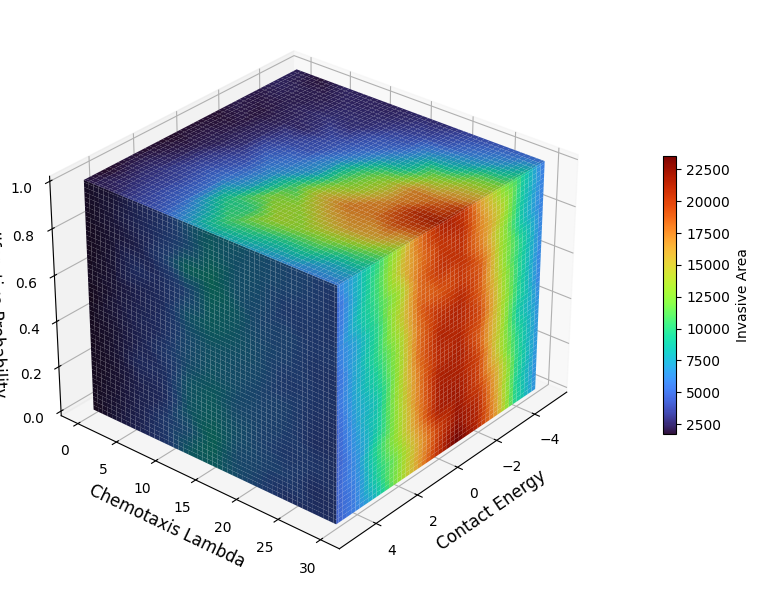

/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_15880/3831526550.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


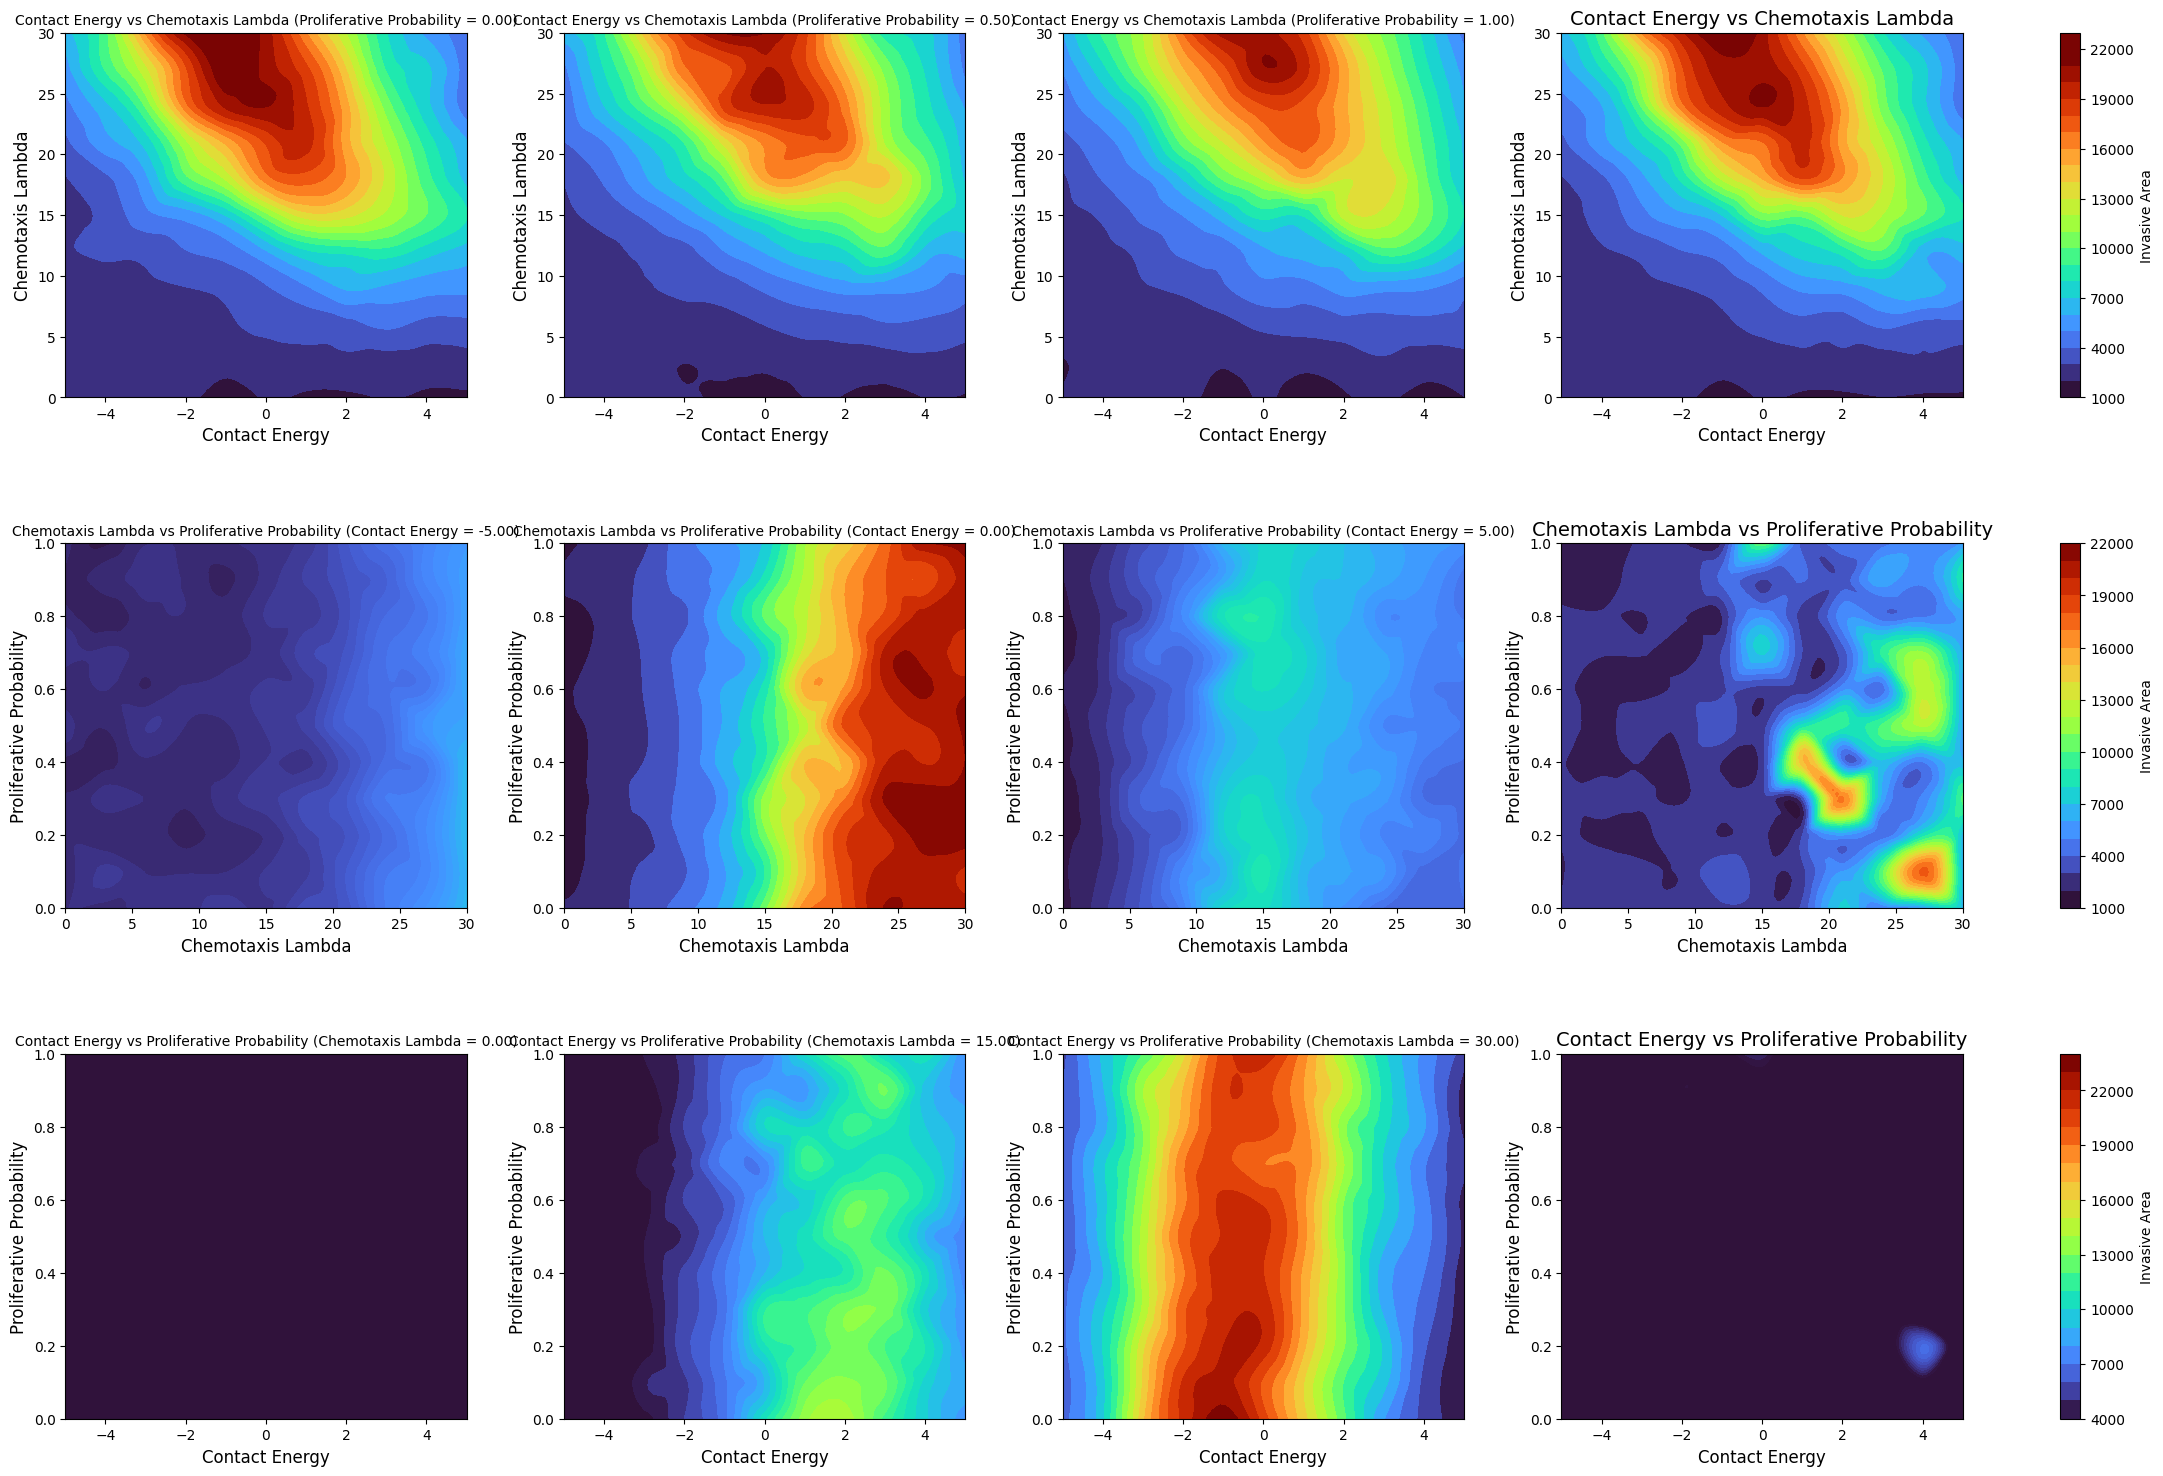

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Invasive_Area_Mean.csv" 
df = pd.read_csv(file_path)

# Extract data from the dataset
x = df["Contact Energy"].values  
y = df["Chemotaxis Lambda"].values  
z = df["Proliferative Probability"].values  
c = df["Invasive Area"].values  

# Normalize the invasive area for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Define the cube boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

# Create meshgrid for cube faces
X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate color values across cube faces
grid_points = np.array([x, y, z]).T
grid_values = c_norm

C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())  # Max Y
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())  # Max X
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())  # Max Z

# Normalize colors for each face separately
C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Create figure for the cube face visualization
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Define colormap normalization
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
colormap = cm.turbo

# Plot cube faces with color mapping
ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)  # Max Y face
ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)  # Max X face
ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)  # Max Z face

# Set axis labels
ax.set_xlabel("Contact Energy", fontsize=12)
ax.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax.set_zlabel("Proliferative Probability", fontsize=12)

# Adjust viewing angle
ax.view_init(elev=30, azim=40)

# Add colorbar
mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
fig.colorbar(mappable, ax=ax, fraction=0.02, pad=0.1, label='Invasive Area')

# Show cube plot
plt.tight_layout()
plt.show()

# --------------------------------------
# Generate 2D Plots
# --------------------------------------

# Define midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Function to compute colorbar range from a specific plot
def compute_plot_vrange(fixed_param, fixed_val, param1, param2):
    mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
    subset = df[mask]
    X, Y = np.meshgrid(
        np.linspace(subset[param1].min(), subset[param1].max(), 100),
        np.linspace(subset[param2].min(), subset[param2].max(), 100)
    )
    Z = griddata((subset[param1], subset[param2]), subset["Invasive Area"], (X, Y), method='cubic')
    return np.nanmin(Z), np.nanmax(Z)

# Function to plot 2D contours for fixed parameter values
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label, vmin, vmax):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        if subset.empty:
            continue
        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100)
        )
        Z = griddata((subset[param1], subset[param2]), subset["Invasive Area"], (X, Y), method='cubic')
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Invasive Area"], (X, Y), method='nearest')
        contour = ax[i].contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)

# Function to plot a single 2D contour plot
def plot_2D_contour(ax, param1, param2, param1_label, param2_label, vmin, vmax):
    X, Y = np.meshgrid(
        np.linspace(df[param1].min(), df[param1].max(), 100),
        np.linspace(df[param2].min(), df[param2].max(), 100))
    Z = griddata((df[param1], df[param2]), df["Invasive Area"], (X, Y), method='cubic')
    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    return contour

# Create figure and custom GridSpec for shared colorbars
fig = plt.figure(figsize=(26, 18))
gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
axes = np.empty((3, 4), dtype=object)

# Generate axes grid
for row in range(3):
    for col in range(4):
        axes[row, col] = fig.add_subplot(gs[row, col])

# Define plot combinations and fixed parameter sets
plot_params = [
    ("Proliferative Probability", [z.min(), z_half, z.max()], "Contact Energy", "Chemotaxis Lambda"),
    ("Contact Energy", [x.min(), x_half_new, x.max()], "Chemotaxis Lambda", "Proliferative Probability"),
    ("Chemotaxis Lambda", [y.min(), y_half_new, y.max()], "Contact Energy", "Proliferative Probability")
]

# Use a single value per row to compute vmin/vmax
vmin1, vmax1 = compute_plot_vrange(plot_params[0][0], plot_params[0][1][1], plot_params[0][2], plot_params[0][3])
vmin2, vmax2 = compute_plot_vrange(plot_params[1][0], plot_params[1][1][1], plot_params[1][2], plot_params[1][3])
vmin3, vmax3 = compute_plot_vrange(plot_params[2][0], plot_params[2][1][2], plot_params[2][2], plot_params[2][3])

# Row 1
plot_fixed_param_contours(axes[0, :3], *plot_params[0], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
contour1 = plot_2D_contour(axes[0, 3], plot_params[0][2], plot_params[0][3], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
fig.colorbar(contour1, cax=fig.add_subplot(gs[0, 4]), label="Invasive Area")

# Row 2
plot_fixed_param_contours(axes[1, :3], *plot_params[1], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
contour2 = plot_2D_contour(axes[1, 3], plot_params[1][2], plot_params[1][3], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
fig.colorbar(axes[1, 1].collections[0], cax=fig.add_subplot(gs[1, 4]), label="Invasive Area")

# Row 3
plot_fixed_param_contours(axes[2, :3], *plot_params[2], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
contour3 = plot_2D_contour(axes[2, 3], plot_params[2][2], plot_params[2][3], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
fig.colorbar(axes[2, 2].collections[0], cax=fig.add_subplot(gs[2, 4]), label="Invasive Area")

plt.tight_layout()
plt.show()


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Invasive_Area_Mean.csv"
df = pd.read_csv(file_path)

# Extract data from the dataset
x = df["Contact Energy"].values
y = df["Chemotaxis Lambda"].values
z = df["Proliferative Probability"].values
c = df["Invasive Area"].values
c_norm = (c - c.min()) / (c.max() - c.min())

# Define the cube boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

# Create meshgrid for cube faces
X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate color values across cube faces
grid_points = np.array([x, y, z]).T
C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

# Normalize colors for each face separately
C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Create figure for the cube face visualization
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Define colormap normalization
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
colormap = cm.turbo

# Plot cube faces with color mapping
ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)  # Max Y face
ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)  # Max X face
ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)  # Max Z face

# Set axis labels
ax.set_xlabel("Contact Energy", fontsize=12)
ax.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax.set_zlabel("Proliferative Probability", fontsize=12)

# Adjust viewing angle
ax.view_init(elev=30, azim=40)

# Add colorbar
mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
fig.colorbar(mappable, ax=ax, fraction=0.02, pad=0.1, label='Invasive Area')

# Save 3D cube plot
cube_output_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Invasive_Area_3D_Cube.png"
plt.tight_layout()
plt.savefig(cube_output_path, dpi=1200)
plt.close()
print(f"3D plot saved to: {cube_output_path}")

# ---------------------------
# Generate 2D Contour Plots
# ---------------------------

# Define midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Function to compute colorbar range from a specific plot
def compute_plot_vrange(fixed_param, fixed_val, param1, param2):
    mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
    subset = df[mask]
    X, Y = np.meshgrid(
        np.linspace(subset[param1].min(), subset[param1].max(), 100),
        np.linspace(subset[param2].min(), subset[param2].max(), 100)
    )
    Z = griddata((subset[param1], subset[param2]), subset["Invasive Area"], (X, Y), method='cubic')
    return np.nanmin(Z), np.nanmax(Z)

# Function to plot 2D contours for fixed parameter values
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label, vmin, vmax):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        if subset.empty:
            continue
        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100)
        )
        Z = griddata((subset[param1], subset[param2]), subset["Invasive Area"], (X, Y), method='cubic')
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Invasive Area"], (X, Y), method='nearest')
        ax[i].contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)

# Function to plot a single 2D contour plot
def plot_2D_contour(ax, param1, param2, param1_label, param2_label, vmin, vmax):
    X, Y = np.meshgrid(
        np.linspace(df[param1].min(), df[param1].max(), 100),
        np.linspace(df[param2].min(), df[param2].max(), 100))
    Z = griddata((df[param1], df[param2]), df["Invasive Area"], (X, Y), method='cubic')
    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    return contour

# Create figure and custom GridSpec for shared colorbars
fig = plt.figure(figsize=(26, 18))
gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
axes = np.empty((3, 4), dtype=object)

# Generate axes grid
for row in range(3):
    for col in range(4):
        axes[row, col] = fig.add_subplot(gs[row, col])

# Define plot combinations and fixed parameter sets
plot_params = [
    ("Proliferative Probability", [z.min(), z_half, z.max()], "Contact Energy", "Chemotaxis Lambda"),
    ("Contact Energy", [x.min(), x_half_new, x.max()], "Chemotaxis Lambda", "Proliferative Probability"),
    ("Chemotaxis Lambda", [y.min(), y_half_new, y.max()], "Contact Energy", "Proliferative Probability")
]

# Use a single value per row to compute vmin/vmax
vmin1, vmax1 = compute_plot_vrange(plot_params[0][0], plot_params[0][1][1], plot_params[0][2], plot_params[0][3])
vmin2, vmax2 = compute_plot_vrange(plot_params[1][0], plot_params[1][1][1], plot_params[1][2], plot_params[1][3])
vmin3, vmax3 = compute_plot_vrange(plot_params[2][0], plot_params[2][1][2], plot_params[2][2], plot_params[2][3])

# Row 1
plot_fixed_param_contours(axes[0, :3], *plot_params[0], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
contour1 = plot_2D_contour(axes[0, 3], plot_params[0][2], plot_params[0][3], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
fig.colorbar(contour1, cax=fig.add_subplot(gs[0, 4]), label="Invasive Area")

# Row 2
plot_fixed_param_contours(axes[1, :3], *plot_params[1], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
contour2 = plot_2D_contour(axes[1, 3], plot_params[1][2], plot_params[1][3], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
fig.colorbar(axes[1, 1].collections[0], cax=fig.add_subplot(gs[1, 4]), label="Invasive Area")

# Row 3
plot_fixed_param_contours(axes[2, :3], *plot_params[2], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
contour3 = plot_2D_contour(axes[2, 3], plot_params[2][2], plot_params[2][3], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
fig.colorbar(axes[2, 2].collections[0], cax=fig.add_subplot(gs[2, 4]), label="Invasive Area")

# Save 2D contour plot
contour_output_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Invasive_Area_2D_Contours.png"
plt.tight_layout()
plt.savefig(contour_output_path, dpi=1200)
plt.close()
print(f"2D plot saved to: {contour_output_path}")


3D plot saved to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Invasive_Area_3D_Cube.png


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_15880/1367808690.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


2D plot saved to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Invasive_Area_2D_Contours.png


## Infiltrative Area Plot

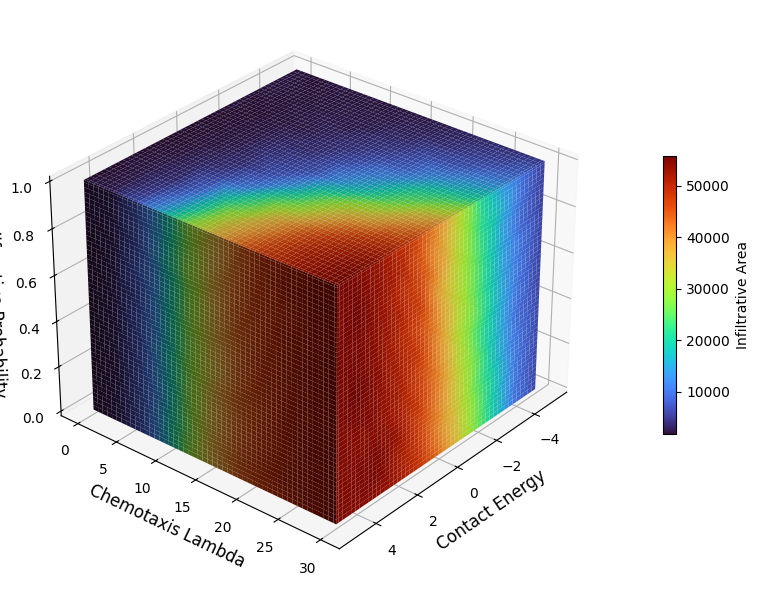

/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_15880/820738406.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


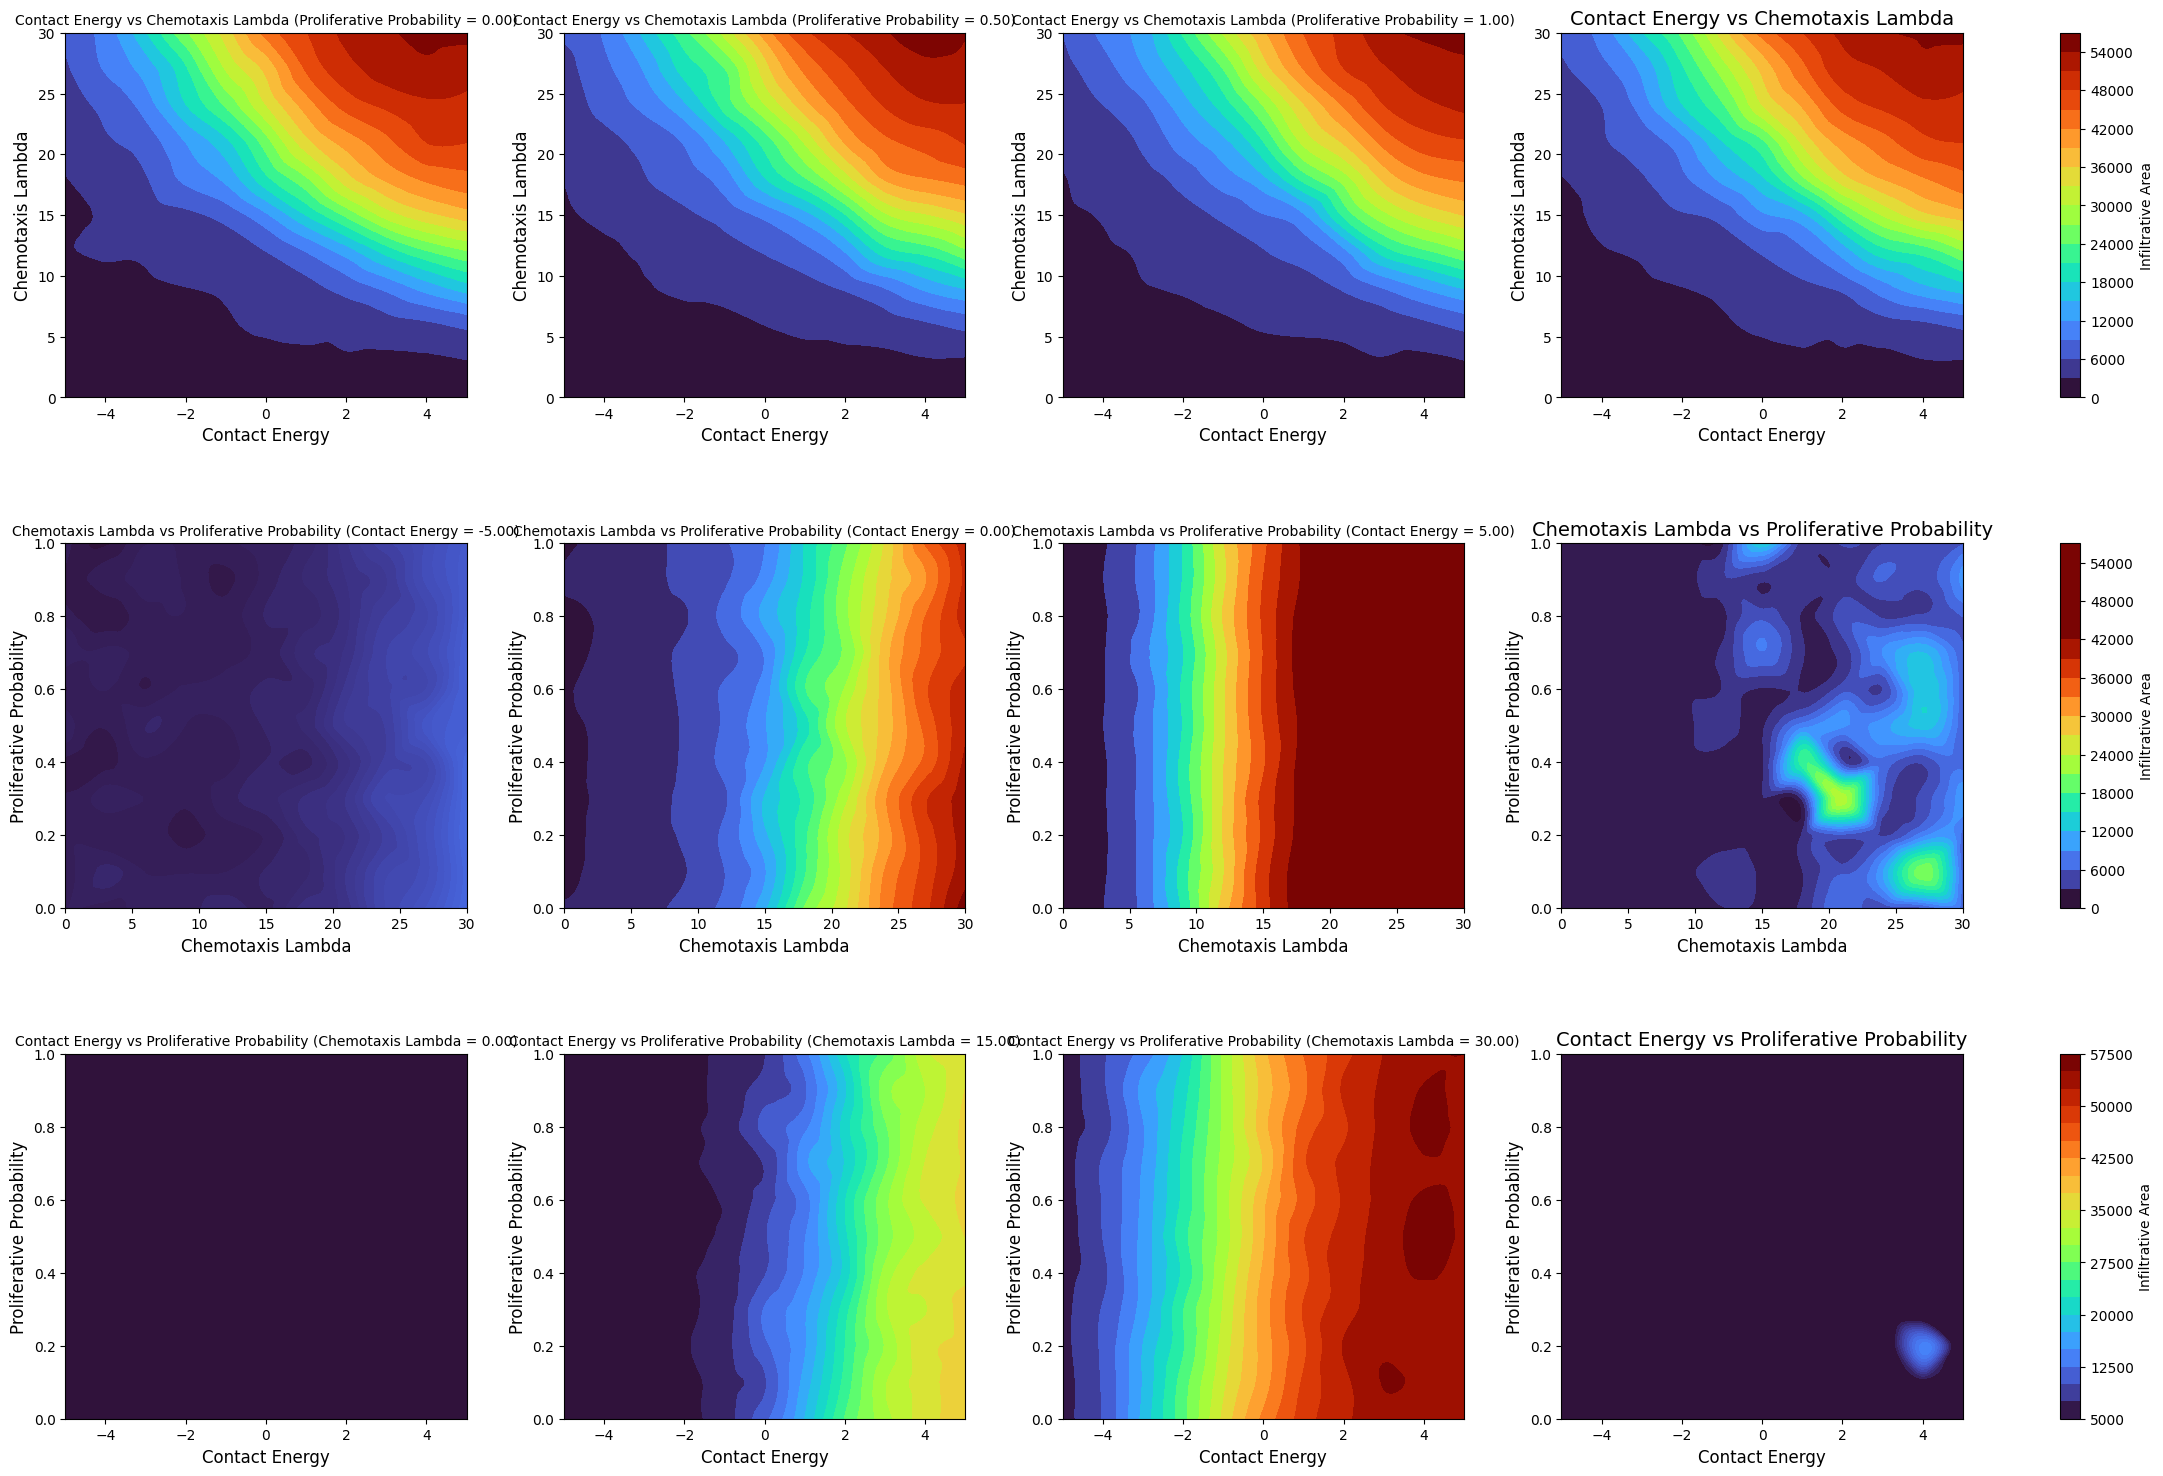

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Infiltrative_Area_Mean.csv" 
df = pd.read_csv(file_path)

# Extract data
x = df["Contact Energy"].values  
y = df["Chemotaxis Lambda"].values  
z = df["Proliferative Probability"].values  
c = df["Infiltrative Area"].values

# Normalize for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Cube boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

# Meshgrids
X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolated cube faces
grid_points = np.array([x, y, z]).T
C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

# Normalize face values
C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Plot cube faces
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colormap = cm.turbo
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)
ax.set_xlabel("Contact Energy", fontsize=12)
ax.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax.set_zlabel("Proliferative Probability", fontsize=12)
ax.view_init(elev=30, azim=40)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), ax=ax, fraction=0.02, pad=0.1, label='Infiltrative Area')
plt.tight_layout()
plt.show()

# Midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Helper to compute vmin/vmax from a slice
def compute_plot_vrange(fixed_param, fixed_val, param1, param2):
    mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
    subset = df[mask]
    X, Y = np.meshgrid(
        np.linspace(subset[param1].min(), subset[param1].max(), 100),
        np.linspace(subset[param2].min(), subset[param2].max(), 100)
    )
    Z = griddata((subset[param1], subset[param2]), subset["Infiltrative Area"], (X, Y), method='cubic')
    return np.nanmin(Z), np.nanmax(Z)

# Plot 2D contours for fixed parameter slices
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label, vmin, vmax):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        if subset.empty:
            continue
        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100))
        Z = griddata((subset[param1], subset[param2]), subset["Infiltrative Area"], (X, Y), method='cubic')
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Infiltrative Area"], (X, Y), method='nearest')
        contour = ax[i].contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)

# Plot full slice
def plot_2D_contour(ax, param1, param2, param1_label, param2_label, vmin, vmax):
    X, Y = np.meshgrid(
        np.linspace(df[param1].min(), df[param1].max(), 100),
        np.linspace(df[param2].min(), df[param2].max(), 100))
    Z = griddata((df[param1], df[param2]), df["Infiltrative Area"], (X, Y), method='cubic')
    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    return contour

# Subplots with shared colorbar strategy
fig = plt.figure(figsize=(26, 18))
gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
axes = np.empty((3, 4), dtype=object)
for r in range(3):
    for c in range(4):
        axes[r, c] = fig.add_subplot(gs[r, c])

plot_params = [
    ("Proliferative Probability", [z.min(), z_half, z.max()], "Contact Energy", "Chemotaxis Lambda"),
    ("Contact Energy", [x.min(), x_half_new, x.max()], "Chemotaxis Lambda", "Proliferative Probability"),
    ("Chemotaxis Lambda", [y.min(), y_half_new, y.max()], "Contact Energy", "Proliferative Probability")
]

vmin1, vmax1 = compute_plot_vrange(plot_params[0][0], plot_params[0][1][1], plot_params[0][2], plot_params[0][3])
vmin2, vmax2 = compute_plot_vrange(plot_params[1][0], plot_params[1][1][1], plot_params[1][2], plot_params[1][3])
vmin3, vmax3 = compute_plot_vrange(plot_params[2][0], plot_params[2][1][2], plot_params[2][2], plot_params[2][3])

# Row 1
plot_fixed_param_contours(axes[0, :3], *plot_params[0], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
cbar1 = plot_2D_contour(axes[0, 3], plot_params[0][2], plot_params[0][3], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
fig.colorbar(cbar1, cax=fig.add_subplot(gs[0, 4]), label="Infiltrative Area")

# Row 2
plot_fixed_param_contours(axes[1, :3], *plot_params[1], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
cbar2 = plot_2D_contour(axes[1, 3], plot_params[1][2], plot_params[1][3], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
fig.colorbar(axes[1, 2].collections[0], cax=fig.add_subplot(gs[1, 4]), label="Infiltrative Area")

# Row 3
plot_fixed_param_contours(axes[2, :3], *plot_params[2], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
cbar3 = plot_2D_contour(axes[2, 3], plot_params[2][2], plot_params[2][3], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
fig.colorbar(axes[2, 2].collections[0], cax=fig.add_subplot(gs[2, 4]), label="Infiltrative Area")

plt.tight_layout()
plt.show()


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Infiltrative_Area_Mean.csv" 
df = pd.read_csv(file_path)

# Extract data
x = df["Contact Energy"].values  
y = df["Chemotaxis Lambda"].values  
z = df["Proliferative Probability"].values  
c = df["Infiltrative Area"].values

# Normalize for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Cube boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

# Meshgrids
X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolated cube faces
grid_points = np.array([x, y, z]).T
C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

# Normalize face values
C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Plot cube faces
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colormap = cm.turbo
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)
ax.set_xlabel("Contact Energy", fontsize=12)
ax.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax.set_zlabel("Proliferative Probability", fontsize=12)
ax.view_init(elev=30, azim=40)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), ax=ax, fraction=0.02, pad=0.1, label='Infiltrative Area')

# Save the 3D cube plot
cube_output_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Infiltrative_Area_3D_Cube.png"
plt.tight_layout()
plt.savefig(cube_output_path, dpi=1200)
plt.close()
print(f"3D plot saved to: {cube_output_path}")

# Midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Helper to compute vmin/vmax from a slice
def compute_plot_vrange(fixed_param, fixed_val, param1, param2):
    mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
    subset = df[mask]
    X, Y = np.meshgrid(
        np.linspace(subset[param1].min(), subset[param1].max(), 100),
        np.linspace(subset[param2].min(), subset[param2].max(), 100)
    )
    Z = griddata((subset[param1], subset[param2]), subset["Infiltrative Area"], (X, Y), method='cubic')
    return np.nanmin(Z), np.nanmax(Z)

# Plot 2D contours for fixed parameter slices
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label, vmin, vmax):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        if subset.empty:
            continue
        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100))
        Z = griddata((subset[param1], subset[param2]), subset["Infiltrative Area"], (X, Y), method='cubic')
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Infiltrative Area"], (X, Y), method='nearest')
        contour = ax[i].contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)

# Plot full slice
def plot_2D_contour(ax, param1, param2, param1_label, param2_label, vmin, vmax):
    X, Y = np.meshgrid(
        np.linspace(df[param1].min(), df[param1].max(), 100),
        np.linspace(df[param2].min(), df[param2].max(), 100))
    Z = griddata((df[param1], df[param2]), df["Infiltrative Area"], (X, Y), method='cubic')
    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    return contour

# Subplots with shared colorbar strategy
fig = plt.figure(figsize=(26, 18))
gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
axes = np.empty((3, 4), dtype=object)
for r in range(3):
    for c in range(4):
        axes[r, c] = fig.add_subplot(gs[r, c])

plot_params = [
    ("Proliferative Probability", [z.min(), z_half, z.max()], "Contact Energy", "Chemotaxis Lambda"),
    ("Contact Energy", [x.min(), x_half_new, x.max()], "Chemotaxis Lambda", "Proliferative Probability"),
    ("Chemotaxis Lambda", [y.min(), y_half_new, y.max()], "Contact Energy", "Proliferative Probability")
]

vmin1, vmax1 = compute_plot_vrange(plot_params[0][0], plot_params[0][1][1], plot_params[0][2], plot_params[0][3])
vmin2, vmax2 = compute_plot_vrange(plot_params[1][0], plot_params[1][1][1], plot_params[1][2], plot_params[1][3])
vmin3, vmax3 = compute_plot_vrange(plot_params[2][0], plot_params[2][1][2], plot_params[2][2], plot_params[2][3])

# Row 1
plot_fixed_param_contours(axes[0, :3], *plot_params[0], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
cbar1 = plot_2D_contour(axes[0, 3], plot_params[0][2], plot_params[0][3], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
fig.colorbar(cbar1, cax=fig.add_subplot(gs[0, 4]), label="Infiltrative Area")

# Row 2
plot_fixed_param_contours(axes[1, :3], *plot_params[1], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
cbar2 = plot_2D_contour(axes[1, 3], plot_params[1][2], plot_params[1][3], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
fig.colorbar(axes[1, 2].collections[0], cax=fig.add_subplot(gs[1, 4]), label="Infiltrative Area")

# Row 3
plot_fixed_param_contours(axes[2, :3], *plot_params[2], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
cbar3 = plot_2D_contour(axes[2, 3], plot_params[2][2], plot_params[2][3], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
fig.colorbar(axes[2, 2].collections[0], cax=fig.add_subplot(gs[2, 4]), label="Infiltrative Area")

# Save the 2D contour plot
contour_output_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Infiltrative_Area_2D_Contours.png"
plt.tight_layout()
plt.savefig(contour_output_path, dpi=1200)
plt.close()
print(f"2D plot saved to: {contour_output_path}")


3D plot saved to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Infiltrative_Area_3D_Cube.png


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_15880/3196243142.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


2D plot saved to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Infiltrative_Area_2D_Contours.png


## Single Defected Cells

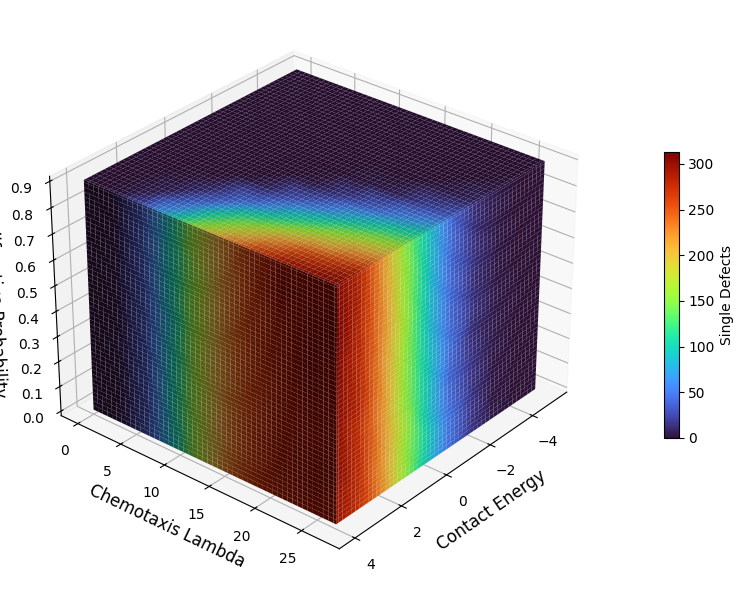

/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_93493/2482913014.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


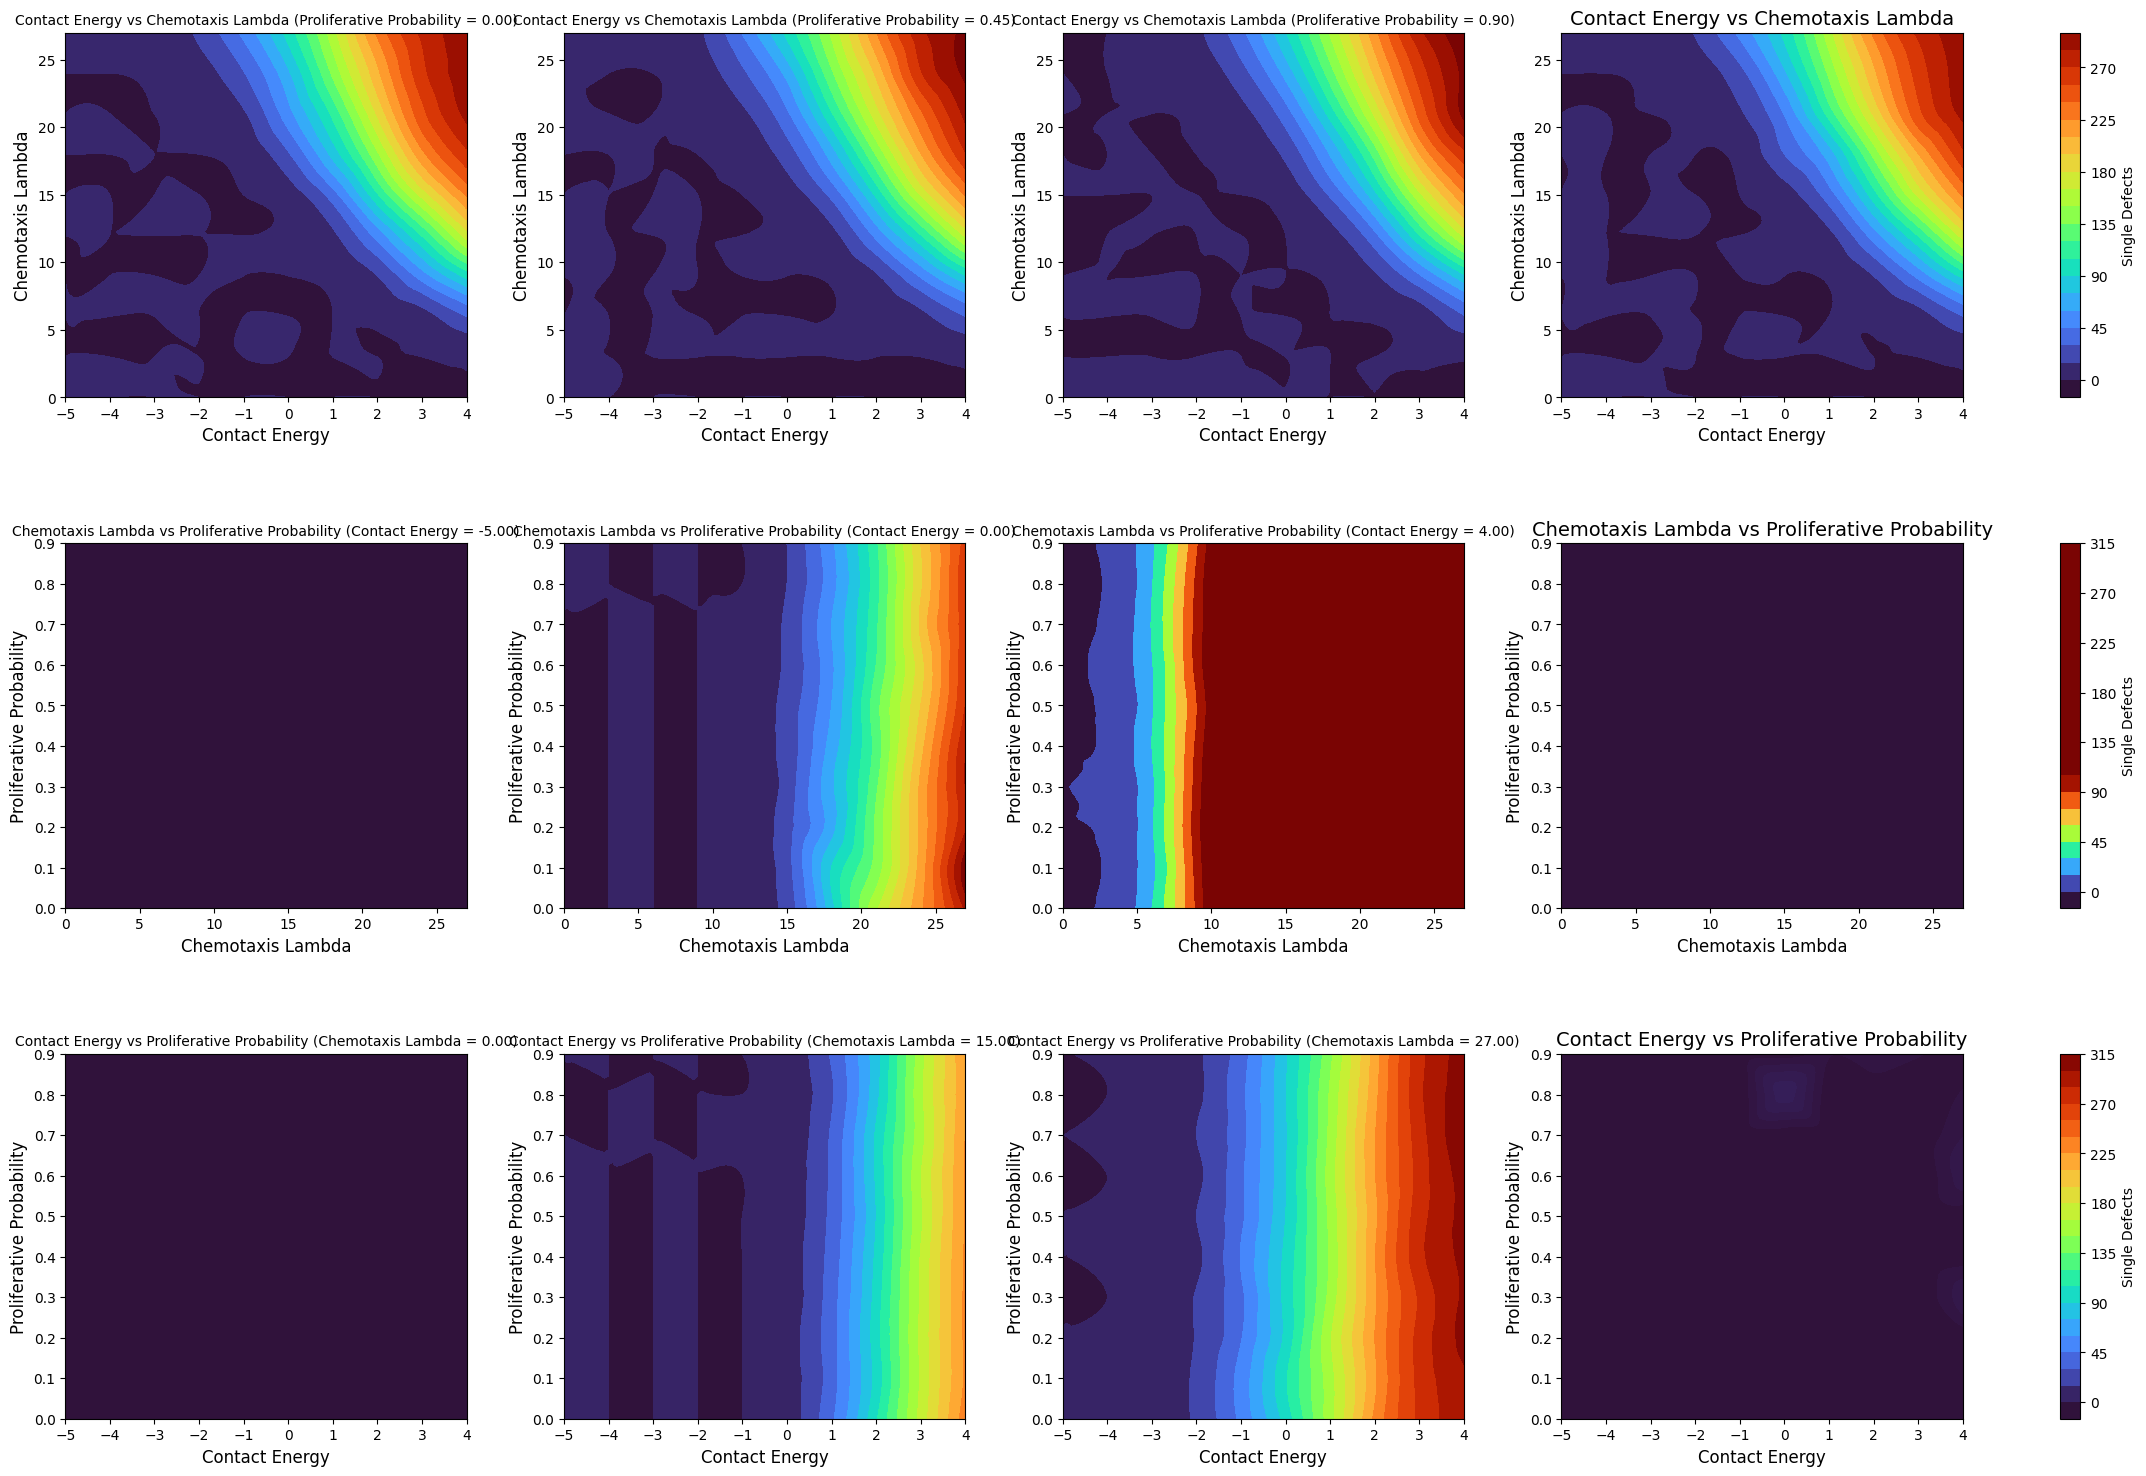

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

# Load dataset
file_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Single_Defects_Mean.csv"
df = pd.read_csv(file_path)

# Extract variables
x = df["Contact Energy"].values
y = df["Chemotaxis Lambda"].values
z = df["Proliferative Probability"].values
c = df["Single Defects"].values

# Normalize for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Meshgrid boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolation
grid_points = np.array([x, y, z]).T
C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Plot cube faces
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colormap = cm.turbo
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)
ax.set_xlabel("Contact Energy", fontsize=12)
ax.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax.set_zlabel("Proliferative Probability", fontsize=12)
ax.view_init(elev=30, azim=40)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), ax=ax, fraction=0.02, pad=0.1, label='Single Defects')
plt.tight_layout()
plt.show()

# Midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Helper to compute color range for single slice
def compute_plot_vrange(fixed_param, fixed_val, param1, param2):
    mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
    subset = df[mask]
    X, Y = np.meshgrid(
        np.linspace(subset[param1].min(), subset[param1].max(), 100),
        np.linspace(subset[param2].min(), subset[param2].max(), 100))
    Z = griddata((subset[param1], subset[param2]), subset["Single Defects"], (X, Y), method='cubic')
    return np.nanmin(Z), np.nanmax(Z)

# Plot fixed slices
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label, vmin, vmax):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        if subset.empty:
            continue
        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100))
        Z = griddata((subset[param1], subset[param2]), subset["Single Defects"], (X, Y), method='cubic')
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Single Defects"], (X, Y), method='nearest')
        ax[i].contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)

# Full contour
def plot_2D_contour(ax, param1, param2, param1_label, param2_label, vmin, vmax):
    X, Y = np.meshgrid(
        np.linspace(df[param1].min(), df[param1].max(), 100),
        np.linspace(df[param2].min(), df[param2].max(), 100))
    Z = griddata((df[param1], df[param2]), df["Single Defects"], (X, Y), method='cubic')
    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    return contour

# Shared colorbar grid
fig = plt.figure(figsize=(26, 18))
gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
axes = np.empty((3, 4), dtype=object)
for r in range(3):
    for c in range(4):
        axes[r, c] = fig.add_subplot(gs[r, c])

plot_params = [
    ("Proliferative Probability", [z.min(), z_half, z.max()], "Contact Energy", "Chemotaxis Lambda"),
    ("Contact Energy", [x.min(), x_half_new, x.max()], "Chemotaxis Lambda", "Proliferative Probability"),
    ("Chemotaxis Lambda", [y.min(), y_half_new, y.max()], "Contact Energy", "Proliferative Probability")
]

vmin1, vmax1 = compute_plot_vrange(plot_params[0][0], plot_params[0][1][1], plot_params[0][2], plot_params[0][3])
vmin2, vmax2 = compute_plot_vrange(plot_params[1][0], plot_params[1][1][1], plot_params[1][2], plot_params[1][3])
vmin3, vmax3 = compute_plot_vrange(plot_params[2][0], plot_params[2][1][2], plot_params[2][2], plot_params[2][3])

# Row 1
plot_fixed_param_contours(axes[0, :3], *plot_params[0], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
cbar1 = plot_2D_contour(axes[0, 3], plot_params[0][2], plot_params[0][3], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
fig.colorbar(cbar1, cax=fig.add_subplot(gs[0, 4]), label="Single Defects")

# Row 2
plot_fixed_param_contours(axes[1, :3], *plot_params[1], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
cbar2 = plot_2D_contour(axes[1, 3], plot_params[1][2], plot_params[1][3], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
fig.colorbar(axes[1, 2].collections[0], cax=fig.add_subplot(gs[1, 4]), label="Single Defects")

# Row 3
plot_fixed_param_contours(axes[2, :3], *plot_params[2], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
cbar3 = plot_2D_contour(axes[2, 3], plot_params[2][2], plot_params[2][3], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
fig.colorbar(axes[2, 2].collections[0], cax=fig.add_subplot(gs[2, 4]), label="Single Defects")

plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

# Load dataset
file_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Single_Defects_Mean.csv"
df = pd.read_csv(file_path)

# Extract variables
x = df["Contact Energy"].values
y = df["Chemotaxis Lambda"].values
z = df["Proliferative Probability"].values
c = df["Single Defects"].values

# Normalize for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Meshgrid boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolation
grid_points = np.array([x, y, z]).T
C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Plot cube faces
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colormap = cm.turbo
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)
ax.set_xlabel("Contact Energy", fontsize=12)
ax.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax.set_zlabel("Proliferative Probability", fontsize=12)
ax.view_init(elev=30, azim=40)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), ax=ax, fraction=0.02, pad=0.1, label='Single Defects')

# Save 3D cube plot
cube_output_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Single_Defects_3D_Cube.png"
plt.tight_layout()
plt.savefig(cube_output_path, dpi=1200)
plt.close()
print(f"3D plot saved to: {cube_output_path}")

# Midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Helper to compute color range for single slice
def compute_plot_vrange(fixed_param, fixed_val, param1, param2):
    mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
    subset = df[mask]
    X, Y = np.meshgrid(
        np.linspace(subset[param1].min(), subset[param1].max(), 100),
        np.linspace(subset[param2].min(), subset[param2].max(), 100))
    Z = griddata((subset[param1], subset[param2]), subset["Single Defects"], (X, Y), method='cubic')
    return np.nanmin(Z), np.nanmax(Z)

# Plot fixed slices
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label, vmin, vmax):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        if subset.empty:
            continue
        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100))
        Z = griddata((subset[param1], subset[param2]), subset["Single Defects"], (X, Y), method='cubic')
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Single Defects"], (X, Y), method='nearest')
        ax[i].contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)

# Full contour
def plot_2D_contour(ax, param1, param2, param1_label, param2_label, vmin, vmax):
    X, Y = np.meshgrid(
        np.linspace(df[param1].min(), df[param1].max(), 100),
        np.linspace(df[param2].min(), df[param2].max(), 100))
    Z = griddata((df[param1], df[param2]), df["Single Defects"], (X, Y), method='cubic')
    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    return contour

# Shared colorbar grid
fig = plt.figure(figsize=(26, 18))
gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
axes = np.empty((3, 4), dtype=object)
for r in range(3):
    for c in range(4):
        axes[r, c] = fig.add_subplot(gs[r, c])

plot_params = [
    ("Proliferative Probability", [z.min(), z_half, z.max()], "Contact Energy", "Chemotaxis Lambda"),
    ("Contact Energy", [x.min(), x_half_new, x.max()], "Chemotaxis Lambda", "Proliferative Probability"),
    ("Chemotaxis Lambda", [y.min(), y_half_new, y.max()], "Contact Energy", "Proliferative Probability")
]

vmin1, vmax1 = compute_plot_vrange(plot_params[0][0], plot_params[0][1][1], plot_params[0][2], plot_params[0][3])
vmin2, vmax2 = compute_plot_vrange(plot_params[1][0], plot_params[1][1][1], plot_params[1][2], plot_params[1][3])
vmin3, vmax3 = compute_plot_vrange(plot_params[2][0], plot_params[2][1][2], plot_params[2][2], plot_params[2][3])

# Row 1
plot_fixed_param_contours(axes[0, :3], *plot_params[0], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
cbar1 = plot_2D_contour(axes[0, 3], plot_params[0][2], plot_params[0][3], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
fig.colorbar(cbar1, cax=fig.add_subplot(gs[0, 4]), label="Single Defects")

# Row 2
plot_fixed_param_contours(axes[1, :3], *plot_params[1], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
cbar2 = plot_2D_contour(axes[1, 3], plot_params[1][2], plot_params[1][3], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
fig.colorbar(axes[1, 2].collections[0], cax=fig.add_subplot(gs[1, 4]), label="Single Defects")

# Row 3
plot_fixed_param_contours(axes[2, :3], *plot_params[2], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
cbar3 = plot_2D_contour(axes[2, 3], plot_params[2][2], plot_params[2][3], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
fig.colorbar(axes[2, 2].collections[0], cax=fig.add_subplot(gs[2, 4]), label="Single Defects")

# Save 2D contour grid
contour_output_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Single_Defects_2D_Contours.png"
plt.tight_layout()
plt.savefig(contour_output_path, dpi=1200)
plt.close()
print(f"2D plot saved to: {contour_output_path}")


3D plot saved to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Single_Defects_3D_Cube.png


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_15880/1115875099.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


2D plot saved to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Single_Defects_2D_Contours.png


## Number of Finger-like Potrusions

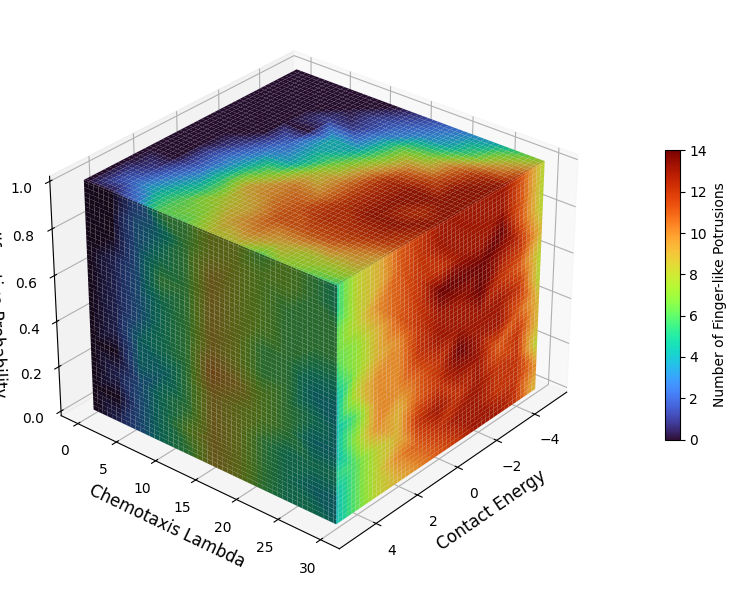

/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_15880/526112560.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


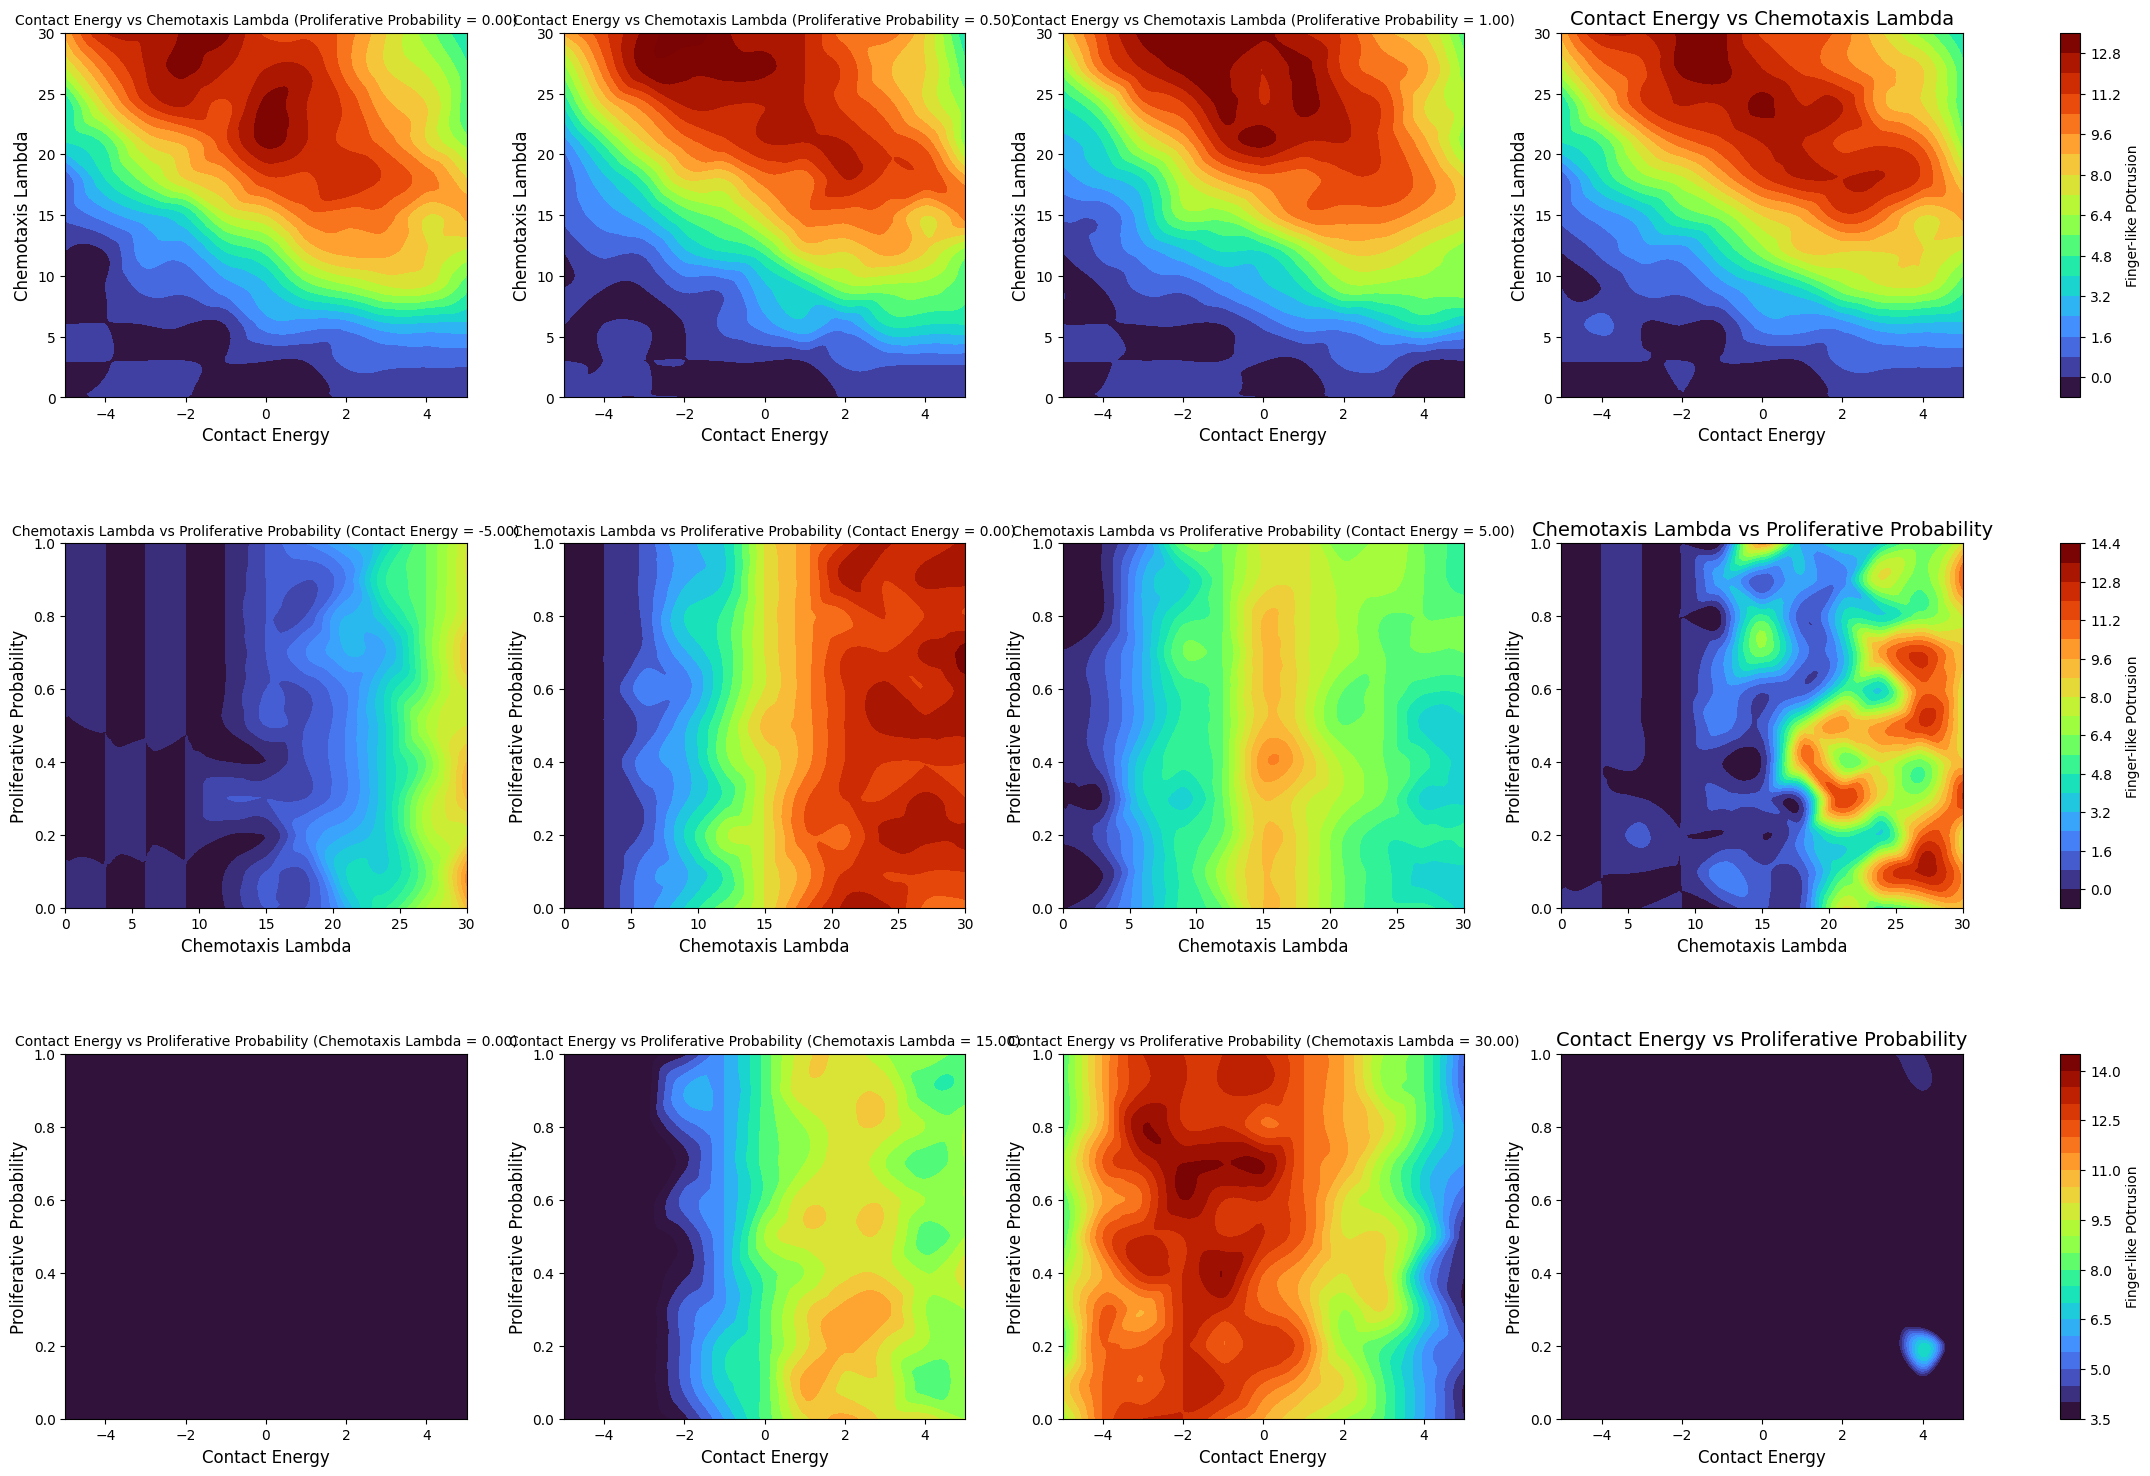

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Fingers_mean.csv" 
df = pd.read_csv(file_path)

# Extract variables
x = df["Contact Energy"].values
y = df["Chemotaxis Lambda"].values
z = df["Proliferative Probability"].values
c = df["Fingers"].values

# Normalize for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Cube boundaries and grids
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate cube faces
grid_points = np.array([x, y, z]).T
C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Plot cube faces
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colormap = cm.turbo
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)
ax.set_xlabel("Contact Energy", fontsize=12)
ax.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax.set_zlabel("Proliferative Probability", fontsize=12)
ax.view_init(elev=30, azim=40)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), ax=ax, fraction=0.02, pad=0.1, label='Number of Finger-like Potrusions')
plt.tight_layout()
plt.show()

# Midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Compute color range for one slice
def compute_plot_vrange(fixed_param, fixed_val, param1, param2):
    mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
    subset = df[mask]
    X, Y = np.meshgrid(
        np.linspace(subset[param1].min(), subset[param1].max(), 100),
        np.linspace(subset[param2].min(), subset[param2].max(), 100))
    Z = griddata((subset[param1], subset[param2]), subset["Fingers"], (X, Y), method='cubic')
    return np.nanmin(Z), np.nanmax(Z)

# Plot fixed param slices
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label, vmin, vmax):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        if subset.empty:
            continue
        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100))
        Z = griddata((subset[param1], subset[param2]), subset["Fingers"], (X, Y), method='cubic')
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Fingers"], (X, Y), method='nearest')
        ax[i].contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)

# Full surface contour
def plot_2D_contour(ax, param1, param2, param1_label, param2_label, vmin, vmax):
    X, Y = np.meshgrid(
        np.linspace(df[param1].min(), df[param1].max(), 100),
        np.linspace(df[param2].min(), df[param2].max(), 100))
    Z = griddata((df[param1], df[param2]), df["Fingers"], (X, Y), method='cubic')
    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    return contour

# Subplots
fig = plt.figure(figsize=(26, 18))
gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
axes = np.empty((3, 4), dtype=object)
for r in range(3):
    for c in range(4):
        axes[r, c] = fig.add_subplot(gs[r, c])

plot_params = [
    ("Proliferative Probability", [z.min(), z_half, z.max()], "Contact Energy", "Chemotaxis Lambda"),
    ("Contact Energy", [x.min(), x_half_new, x.max()], "Chemotaxis Lambda", "Proliferative Probability"),
    ("Chemotaxis Lambda", [y.min(), y_half_new, y.max()], "Contact Energy", "Proliferative Probability")
]

# Update to use value from plot (1,3)
vmin1, vmax1 = compute_plot_vrange(plot_params[0][0], plot_params[0][1][2], plot_params[0][2], plot_params[0][3])
vmin2, vmax2 = compute_plot_vrange(plot_params[1][0], plot_params[1][1][1], plot_params[1][2], plot_params[1][3])
vmin3, vmax3 = compute_plot_vrange(plot_params[2][0], plot_params[2][1][2], plot_params[2][2], plot_params[2][3])

# Row 1
plot_fixed_param_contours(axes[0, :3], *plot_params[0], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
cbar1 = plot_2D_contour(axes[0, 3], plot_params[0][2], plot_params[0][3], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
fig.colorbar(axes[0, 2].collections[0], cax=fig.add_subplot(gs[0, 4]), label="Finger-like POtrusion")

# Row 2
plot_fixed_param_contours(axes[1, :3], *plot_params[1], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
cbar2 = plot_2D_contour(axes[1, 3], plot_params[1][2], plot_params[1][3], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
fig.colorbar(axes[1, 1].collections[0], cax=fig.add_subplot(gs[1, 4]), label="Finger-like POtrusion")

# Row 3
plot_fixed_param_contours(axes[2, :3], *plot_params[2], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
cbar3 = plot_2D_contour(axes[2, 3], plot_params[2][2], plot_params[2][3], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
fig.colorbar(axes[2, 2].collections[0], cax=fig.add_subplot(gs[2, 4]), label="Finger-like POtrusion")

plt.tight_layout()
plt.show()


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Fingers_mean.csv" 
df = pd.read_csv(file_path)

# Extract variables
x = df["Contact Energy"].values
y = df["Chemotaxis Lambda"].values
z = df["Proliferative Probability"].values
c = df["Fingers"].values

# Normalize for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Cube boundaries and grids
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate cube faces
grid_points = np.array([x, y, z]).T
C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Plot cube faces
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colormap = cm.turbo
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)
ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)
ax.set_xlabel("Contact Energy", fontsize=12)
ax.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax.set_zlabel("Proliferative Probability", fontsize=12)
ax.view_init(elev=30, azim=40)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), ax=ax, fraction=0.02, pad=0.1, label='Number of Finger-like Protrusions')

# Save the 3D plot
output_3d_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Fingers_3D_Cube.png"
plt.tight_layout()
plt.savefig(output_3d_path, dpi=1200)
plt.close()
print(f"3D plot saved to: {output_3d_path}")

# Midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Compute color range for one slice
def compute_plot_vrange(fixed_param, fixed_val, param1, param2):
    mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
    subset = df[mask]
    X, Y = np.meshgrid(
        np.linspace(subset[param1].min(), subset[param1].max(), 100),
        np.linspace(subset[param2].min(), subset[param2].max(), 100))
    Z = griddata((subset[param1], subset[param2]), subset["Fingers"], (X, Y), method='cubic')
    return np.nanmin(Z), np.nanmax(Z)

# Plot fixed param slices
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label, vmin, vmax):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        if subset.empty:
            continue
        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100))
        Z = griddata((subset[param1], subset[param2]), subset["Fingers"], (X, Y), method='cubic')
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Fingers"], (X, Y), method='nearest')
        ax[i].contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)

# Full surface contour
def plot_2D_contour(ax, param1, param2, param1_label, param2_label, vmin, vmax):
    X, Y = np.meshgrid(
        np.linspace(df[param1].min(), df[param1].max(), 100),
        np.linspace(df[param2].min(), df[param2].max(), 100))
    Z = griddata((df[param1], df[param2]), df["Fingers"], (X, Y), method='cubic')
    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    return contour

# Subplots
fig = plt.figure(figsize=(26, 18))
gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
axes = np.empty((3, 4), dtype=object)
for r in range(3):
    for c in range(4):
        axes[r, c] = fig.add_subplot(gs[r, c])

plot_params = [
    ("Proliferative Probability", [z.min(), z_half, z.max()], "Contact Energy", "Chemotaxis Lambda"),
    ("Contact Energy", [x.min(), x_half_new, x.max()], "Chemotaxis Lambda", "Proliferative Probability"),
    ("Chemotaxis Lambda", [y.min(), y_half_new, y.max()], "Contact Energy", "Proliferative Probability")
]

# Use specific fixed slice values
vmin1, vmax1 = compute_plot_vrange(plot_params[0][0], plot_params[0][1][2], plot_params[0][2], plot_params[0][3])
vmin2, vmax2 = compute_plot_vrange(plot_params[1][0], plot_params[1][1][1], plot_params[1][2], plot_params[1][3])
vmin3, vmax3 = compute_plot_vrange(plot_params[2][0], plot_params[2][1][2], plot_params[2][2], plot_params[2][3])

# Row 1
plot_fixed_param_contours(axes[0, :3], *plot_params[0], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
cbar1 = plot_2D_contour(axes[0, 3], plot_params[0][2], plot_params[0][3], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
fig.colorbar(axes[0, 2].collections[0], cax=fig.add_subplot(gs[0, 4]), label="Finger-like Protrusions")

# Row 2
plot_fixed_param_contours(axes[1, :3], *plot_params[1], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
cbar2 = plot_2D_contour(axes[1, 3], plot_params[1][2], plot_params[1][3], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
fig.colorbar(axes[1, 1].collections[0], cax=fig.add_subplot(gs[1, 4]), label="Finger-like Protrusions")

# Row 3
plot_fixed_param_contours(axes[2, :3], *plot_params[2], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
cbar3 = plot_2D_contour(axes[2, 3], plot_params[2][2], plot_params[2][3], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
fig.colorbar(axes[2, 2].collections[0], cax=fig.add_subplot(gs[2, 4]), label="Finger-like Protrusions")

# Save 2D contour plots
output_2d_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Fingers_2D_Contours.png"
plt.tight_layout()
plt.savefig(output_2d_path, dpi=1200)
plt.close()
print(f"2D plot saved to: {output_2d_path}")


3D plot saved to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Fingers_3D_Cube.png


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_15880/2107597115.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


2D plot saved to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Fingers_2D_Contours.png


## Combined

/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_2176/2399997699.py:85: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


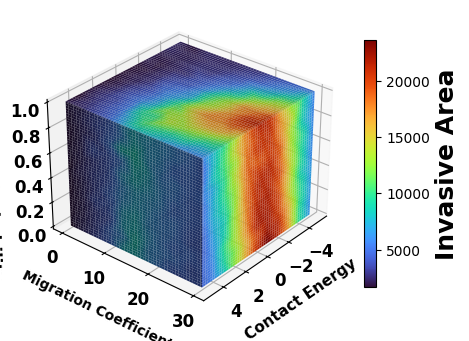

/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_2176/2399997699.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


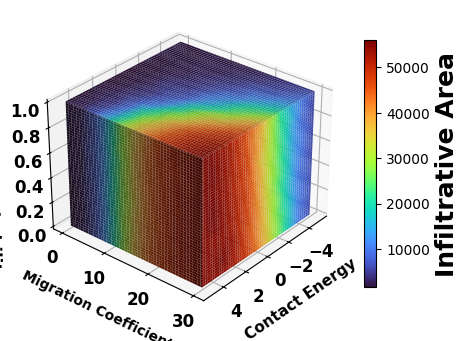

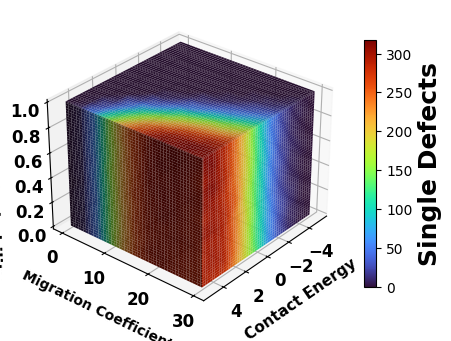

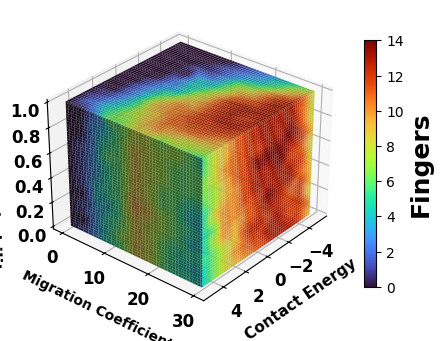

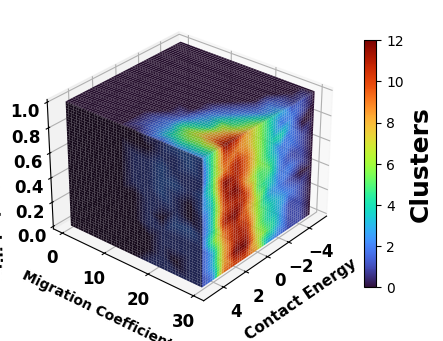

['Plots saved: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Invasive_Area_3D_Cube.png, /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Invasive_Area_2D_Contours.png',
 'Plots saved: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Infiltrative_Area_3D_Cube.png, /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Infiltrative_Area_2D_Contours.png',
 'Plots saved: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Single_Defects_3D_Cube.png, /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Single_Defects_2D_Contours.png',
 'Plots saved: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Fingers_3D_Cube.png, /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Fingers_2D_Contours.png',
 'Plots saved: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/Clusters_3D_Cube.png, /Users/sheriffakeeb/D

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec


base_output_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/"
# New file path
combined_file_path = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Combined_Metrics_Mean.csv"
df_all = pd.read_csv(combined_file_path)

# Updated list of metrics
features = [
    ("Invasive Area", "Invasive Area"),
    ("Infiltrative Area", "Infiltrative Area"),
    ("Single Defects", "Single Defects"),
    ("Fingers", "Fingers"),
    ("Clusters", "Clusters")
]

def process_feature_from_combined_df(df, feature_column, label_name):
    x = df["Contact Energy"].values
    y = df["Chemotaxis Lambda"].values
    z = df["Proliferative Probability"].values
    c = df[feature_column].values

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    z_min, z_max = z.min(), z.max()
    x_half_new = 0
    y_half_new = 15
    z_half = (z.max() + z.min()) / 2

    # --- 3D PLOT ---
    X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
    Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
    X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    grid_points = np.array([x, y, z]).T
    C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
    C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
    C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection='3d')
    colormap = cm.turbo
    norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())

    ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap((C_left - c.min()) / (c.max() - c.min())), edgecolor='none', alpha=1.0)
    ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap((C_right - c.min()) / (c.max() - c.min())), edgecolor='none', alpha=1.0)
    ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap((C_top - c.min()) / (c.max() - c.min())), edgecolor='none', alpha=1.0)
    ax.set_xlabel("Contact Energy", fontsize=11, weight ='bold')
    ax.set_ylabel("Migration Coefficient", fontsize=10, weight ='bold')
    ax.set_zlabel("Proliferative Probability", fontsize=12, weight ='bold')
    ax.tick_params(axis='both', which='major', labelsize=12, pad=1)
    ax.zaxis.set_tick_params(labelsize=12, pad=1)
    
    # Bold the tick labels
    for tick in ax.xaxis.get_ticklabels():
        tick.set_fontweight('bold')
    for tick in ax.yaxis.get_ticklabels():
        tick.set_fontweight('bold')
    for tick in ax.zaxis.get_ticklabels():
        tick.set_fontweight('bold')

    ax.view_init(elev=30, azim=40)
    #fig.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), ax=ax, fraction=0.02, pad=0.02, label=label_name)
    cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=colormap),
    ax=ax,
    shrink=0.8,
    aspect=20,
    pad=0.05,

)
    cbar.set_label(label_name, weight='bold', fontsize=18)

    safe_name = feature_column.replace(" ", "_")
    output_3d_path = os.path.join(base_output_path, f"{safe_name}_3D_Cube.png")
    plt.tight_layout()
    plt.savefig(output_3d_path, dpi=300)
    plt.show()



    # --- 2D CONTOUR ---
    fig = plt.figure(figsize=(26, 18))
    gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
    axes = np.empty((3, 4), dtype=object)
    for r in range(3):
        for c in range(4):
            axes[r, c] = fig.add_subplot(gs[r, c])

    plot_params = [
        ("Proliferative Probability", [z.min(), z_half, z.max()], "Contact Energy", "Chemotaxis Lambda"),
        ("Contact Energy", [x.min(), x_half_new, x.max()], "Chemotaxis Lambda", "Proliferative Probability"),
        ("Chemotaxis Lambda", [y.min(), y_half_new, y.max()], "Contact Energy", "Proliferative Probability")
    ]

    def compute_plot_vrange(fixed_param, fixed_val, param1, param2):
        mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
        subset = df[mask]
        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100))
        Z = griddata((subset[param1], subset[param2]), subset[feature_column], (X, Y), method='cubic')
        return np.nanmin(Z), np.nanmax(Z)

    def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label, vmin, vmax):
        for i, val in enumerate(fixed_values):
            mask = np.isclose(df[fixed_param], val, atol=0.1)
            subset = df[mask]
            if subset.empty:
                continue
            X, Y = np.meshgrid(
                np.linspace(subset[param1].min(), subset[param1].max(), 100),
                np.linspace(subset[param2].min(), subset[param2].max(), 100))
            Z = griddata((subset[param1], subset[param2]), subset[feature_column], (X, Y), method='cubic')
            if np.isnan(Z).all():
                Z = griddata((subset[param1], subset[param2]), subset[feature_column], (X, Y), method='nearest')
            ax[i].contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
            ax[i].set_xlabel(param1_label, fontsize=12)
            ax[i].set_ylabel(param2_label, fontsize=12)
            ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)

    def plot_2D_contour(ax, param1, param2, param1_label, param2_label, vmin, vmax):
        X, Y = np.meshgrid(
            np.linspace(df[param1].min(), df[param1].max(), 100),
            np.linspace(df[param2].min(), df[param2].max(), 100))
        Z = griddata((df[param1], df[param2]), df[feature_column], (X, Y), method='cubic')
        contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        ax.set_xlabel(param1_label, fontsize=12)
        ax.set_ylabel(param2_label, fontsize=12)
        ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
        return contour

    vmin1, vmax1 = compute_plot_vrange(plot_params[0][0], plot_params[0][1][1], plot_params[0][2], plot_params[0][3])
    vmin2, vmax2 = compute_plot_vrange(plot_params[1][0], plot_params[1][1][1], plot_params[1][2], plot_params[1][3])
    vmin3, vmax3 = compute_plot_vrange(plot_params[2][0], plot_params[2][1][1], plot_params[2][2], plot_params[2][3])

    plot_fixed_param_contours(axes[0, :3], *plot_params[0], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
    contour1 = plot_2D_contour(axes[0, 3], plot_params[0][2], plot_params[0][3], plot_params[0][2], plot_params[0][3], vmin1, vmax1)
    fig.colorbar(contour1, cax=fig.add_subplot(gs[0, 4]), label=label_name)

    plot_fixed_param_contours(axes[1, :3], *plot_params[1], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
    contour2 = plot_2D_contour(axes[1, 3], plot_params[1][2], plot_params[1][3], plot_params[1][2], plot_params[1][3], vmin2, vmax2)
    fig.colorbar(contour2, cax=fig.add_subplot(gs[1, 4]), label=label_name)

    plot_fixed_param_contours(axes[2, :3], *plot_params[2], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
    contour3 = plot_2D_contour(axes[2, 3], plot_params[2][2], plot_params[2][3], plot_params[2][2], plot_params[2][3], vmin3, vmax3)
    fig.colorbar(contour3, cax=fig.add_subplot(gs[2, 4]), label=label_name)

    output_2d_path = os.path.join(base_output_path, f"{safe_name}_2D_Contours.png")
    plt.tight_layout()
    plt.savefig(output_2d_path, dpi=300)
    plt.close()

    return f"Plots saved: {output_3d_path}, {output_2d_path}"

# Run for all metrics from combined CSV
results_combined = []
for feature_column, label in features:
    result = process_feature_from_combined_df(df_all, feature_column, label)
    results_combined.append(result)

results_combined


### Powerpoint

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from pptx import Presentation
from pptx.util import Inches

# === File Paths ===
input_file = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Data/Combined_Metrics_Mean.csv"
output_dir = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots"
os.makedirs(output_dir, exist_ok=True)

# === Load Data ===
df = pd.read_csv(input_file)

# === Metrics to Process ===
features = [
    ("Invasive Area", "Invasive Area"),
    ("Infiltrative Area", "Infiltrative Area"),
    ("Single Defects", "Single Defects"),
    ("Fingers", "Fingers"),
    ("Clusters", "Clusters")
]

# === Plot Function ===
def generate_plots(df, feature_col, label_name):
    x = df["Contact Energy"]
    y = df["Chemotaxis Lambda"]
    z = df["Proliferative Probability"]
    c = df[feature_col]

    safe_name = feature_col.replace(" ", "_")
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    z_min, z_max = z.min(), z.max()
    z_half = (z_max + z_min) / 2
    x_half_new = 0
    y_half_new = 15

    # 3D PLOT
    X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
    Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
    X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_points = np.array([x, y, z]).T

    C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
    C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
    C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
    cmap = cm.turbo
    ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=cmap((C_left - c.min()) / (c.max() - c.min())), edgecolor='none')
    ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=cmap((C_right - c.min()) / (c.max() - c.min())), edgecolor='none')
    ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=cmap((C_top - c.min()) / (c.max() - c.min())), edgecolor='none')
    ax.set_xlabel("Contact Energy")
    ax.set_ylabel("Chemotaxis Lambda")
    ax.set_zlabel("Proliferative Probability")
    ax.view_init(elev=30, azim=40)
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.02, pad=0.1, label=label_name)
    out_3d = os.path.join(output_dir, f"{safe_name}_3D_Cube.png")
    plt.tight_layout()
    plt.savefig(out_3d, dpi=600)
    plt.close()

    # 2D CONTOURS
    fig = plt.figure(figsize=(26, 18))
    gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)
    axes = np.empty((3, 4), dtype=object)
    for r in range(3):
        for c in range(4):
            axes[r, c] = fig.add_subplot(gs[r, c])

    def compute_vrange(fixed_param, fixed_val, param1, param2):
        mask = np.isclose(df[fixed_param], fixed_val, atol=0.1)
        subset = df[mask]
        X, Y = np.meshgrid(np.linspace(subset[param1].min(), subset[param1].max(), 100),
                           np.linspace(subset[param2].min(), subset[param2].max(), 100))
        Z = griddata((subset[param1], subset[param2]), subset[feature_col], (X, Y), method='cubic')
        return np.nanmin(Z), np.nanmax(Z)

    def plot_slice(ax, fixed_param, val, param1, param2, vmin, vmax):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        X, Y = np.meshgrid(np.linspace(subset[param1].min(), subset[param1].max(), 100),
                           np.linspace(subset[param2].min(), subset[param2].max(), 100))
        Z = griddata((subset[param1], subset[param2]), subset[feature_col], (X, Y), method='cubic')
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset[feature_col], (X, Y), method='nearest')
        contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
        return contour

    param_sets = [
        ("Proliferative Probability", z_half, "Contact Energy", "Chemotaxis Lambda"),
        ("Contact Energy", x_half_new, "Chemotaxis Lambda", "Proliferative Probability"),
        ("Chemotaxis Lambda", y_half_new, "Contact Energy", "Proliferative Probability")
    ]

    for i, (fixed_param, val, p1, p2) in enumerate(param_sets):
        vmin, vmax = compute_vrange(fixed_param, val, p1, p2)
        for j, val_ in enumerate([df[fixed_param].min(), val, df[fixed_param].max()]):
            plot_slice(axes[i, j], fixed_param, val_, p1, p2, vmin, vmax)
            axes[i, j].set_xlabel(p1)
            axes[i, j].set_ylabel(p2)
            axes[i, j].set_title(f"{p1} vs {p2} ({fixed_param}={val_:.2f})")
        contour = plot_slice(axes[i, 3], fixed_param, val, p1, p2, vmin, vmax)
        axes[i, 3].set_title(f"{p1} vs {p2} (all)")
        fig.colorbar(contour, cax=fig.add_subplot(gs[i, 4]), label=label_name)

    out_2d = os.path.join(output_dir, f"{safe_name}_2D_Contours.png")
    plt.tight_layout()
    plt.savefig(out_2d, dpi=600)
    plt.close()

    return out_3d, out_2d

# === Run All Features ===
image_paths = []
for col, label in features:
    paths = generate_plots(df, col, label)
    image_paths.append((label, paths[0], paths[1]))

# === Create PowerPoint ===
pptx_path = os.path.join(output_dir, "TumorInvasion_Metrics_Plots.pptx")
prs = Presentation()
title_slide = prs.slides.add_slide(prs.slide_layouts[0])
title_slide.shapes.title.text = "Tumor Invasion Metrics Visualization"
title_slide.placeholders[1].text = "3D Cubes and 2D Slices of Simulation Metrics"

for label, img3d, img2d in image_paths:
    slide = prs.slides.add_slide(prs.slide_layouts[5])
    slide.shapes.title.text = label
    if os.path.exists(img3d):
        slide.shapes.add_picture(img3d, Inches(0.5), Inches(1.3), width=Inches(4.5))
    if os.path.exists(img2d):
        slide.shapes.add_picture(img2d, Inches(5.0), Inches(1.3), width=Inches(4.5))

prs.save(pptx_path)
print(f"✅ All plots generated and saved in: {output_dir}")
print(f"📊 PowerPoint created: {pptx_path}")


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_15880/55827461.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/sheriffakeeb/myCodes/myEnv/lib/python3.11/site-packages/PIL/Image.py:3368: DecompressionBombWarning: Image size (168480000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


✅ All plots generated and saved in: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots
📊 PowerPoint created: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/2D_and_3D_plots/TumorInvasion_Metrics_Plots.pptx
